# Particle Experiment Analysis
Analysis of data output by script: `particle_sim_sweep.py`<br><br>
**Volume size:**<br>
voxels_z = 1024 voxels_y = 1024 voxels_x = 1024<br>
<br>
**Particles:**<br>



In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("dark_background")

#### Open the particle results DB

In [29]:
PARTICLE_ANALYSIS_CSV = Path(
    "../Data/simulated_particles/particle_experiment_metrics_1024_1024.csv"
)
if not PARTICLE_ANALYSIS_CSV.exists():
    raise FileNotFoundError(PARTICLE_ANALYSIS_CSV)

df_particle_raw = pd.read_csv(PARTICLE_ANALYSIS_CSV)
print(f"Opened particle analysis DB with {len(df_particle_raw)} entries")


Opened particle analysis DB with 570240 entries


#### Organize around columns for analysis

In [30]:
retention_metrics = [
    "peak_contrast_retention",
    "integrated_contrast_retention",
    "peak_cnr_retention",
    "integrated_cnr_retention",
]
particle_position_columns = [
    "z", "y", "x", "radius_xy", "rotated_z", "rotated_y", "rotated_x"
]
seed_average_keys = [
    "bit_depth", "particle_sigma", "amplitude_snr", "interpolation_order",
    "theta_deg", "phi_deg", "particle_id", "top_k",
    *particle_position_columns,
]

#### Partition into no-noise/noise realizations
Average results across the noise realizations maintaining independence of:
- Particle position and sizes (sigmas)
- bit depth (uint8 vs uint16)
- rotation angles ($\theta, \phi$)
- interpolation orders for the rotation
<br><br>
to be used for further analysis


In [31]:
# Data from noise realizations - reduced by averaging the independent results
df_particle_realized_by_particle = (
    df_particle_raw.query("noise_seed >= 0")
    .groupby(seed_average_keys, as_index=False)[retention_metrics]
    .mean()
)

# Add new column indicating the z-displacement after rotation
df_particle_realized_by_particle["z_displacement"] = (
    df_particle_realized_by_particle["rotated_z"]
    - df_particle_realized_by_particle["z"]
)

# No-noise data
df_particle_flat_by_particle = df_particle_raw.query("noise_seed == -1").copy()

# region Data summary
print(f"Raw database rows: {len(df_particle_raw):,}")
print(
    "Seed-averaged realized-noise particle rows: "
    f"{len(df_particle_realized_by_particle):,}"
)
print(f"No-noise particle rows: {len(df_particle_flat_by_particle):,}")
print(
        "Original particle position z planes:",
        sorted( z.item() for z in df_particle_realized_by_particle.z.unique()))
# endregion


Raw database rows: 570,240
Seed-averaged realized-noise particle rows: 95,040
No-noise particle rows: 95,040
Original particle position z planes: [128.0, 256.0, 384.0, 512.0]


## Summary statistics per z-plane and interpolation order
`Caveats:` No accounting for the particle size (sigma) nor position which are all averaged together.
<br>
`Observations:'<br>
- Particle magnitudes were superiorly maintained, and with tighter statstics, with higher order interpolation
- Particle CNRs increased significantly at order 1, primarily due to the low-pass filter effect on the bacground noise. 

In [32]:
# Source-z summary. Error bars are descriptive SEM across the retained
# particle-condition observations, not an independent-particle confidence interval.
z_order_summary = (
    df_particle_realized_by_particle
    .groupby(["z", "interpolation_order"])[retention_metrics]
    .agg(["mean", "median", "std", "count"])
)

display_z_order_summary_table = False
if display_z_order_summary_table:
    display(z_order_summary)


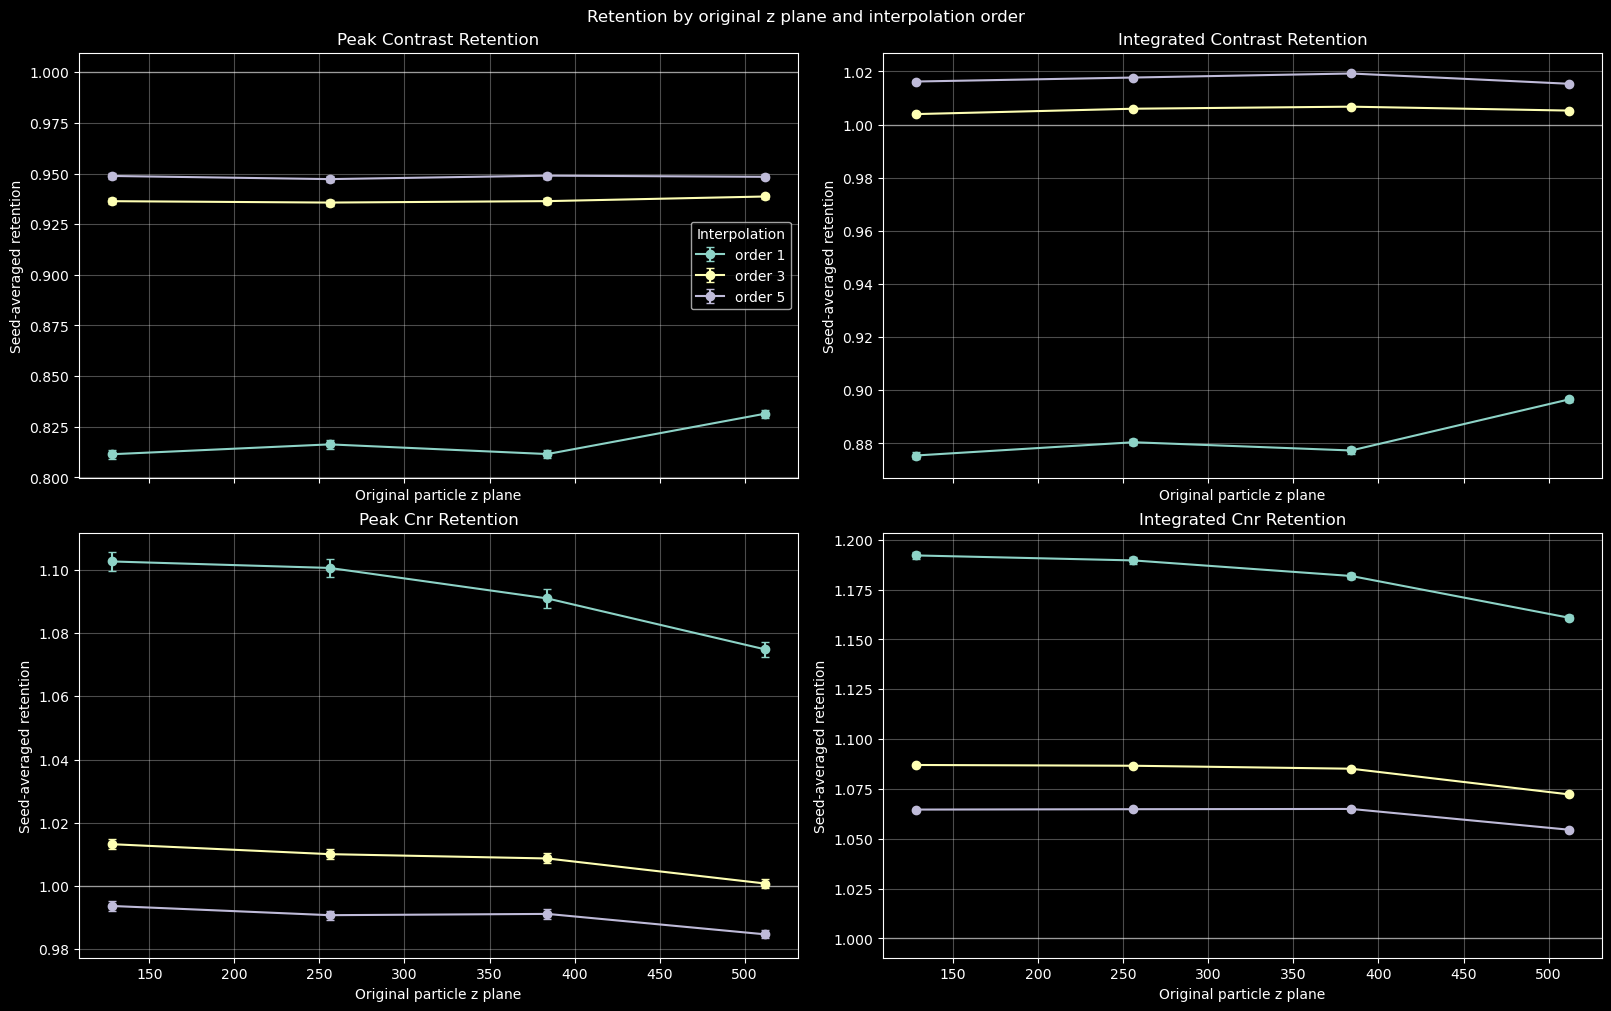

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, layout="constrained")
for axis, metric in zip(axes.flat, retention_metrics, strict=True):
    summary = (
        df_particle_realized_by_particle
        .groupby(["z", "interpolation_order"])[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    for order, group in summary.groupby("interpolation_order"):
        sem = group["std"] / np.sqrt(group["count"])
        axis.errorbar(
            group["z"], group["mean"], yerr=sem,
            marker="o", capsize=3, label=f"order {order}",
        )
    axis.axhline(1.0, color="white", linewidth=1, alpha=0.45)
    axis.set_title(metric.replace("_", " ").title())
    axis.set_xlabel("Original particle z plane")
    axis.set_ylabel("Seed-averaged retention")
    axis.grid(alpha=0.3)
axes[0, 0].legend(title="Interpolation")
fig.suptitle("Retention by original z plane and interpolation order")
plt.show()


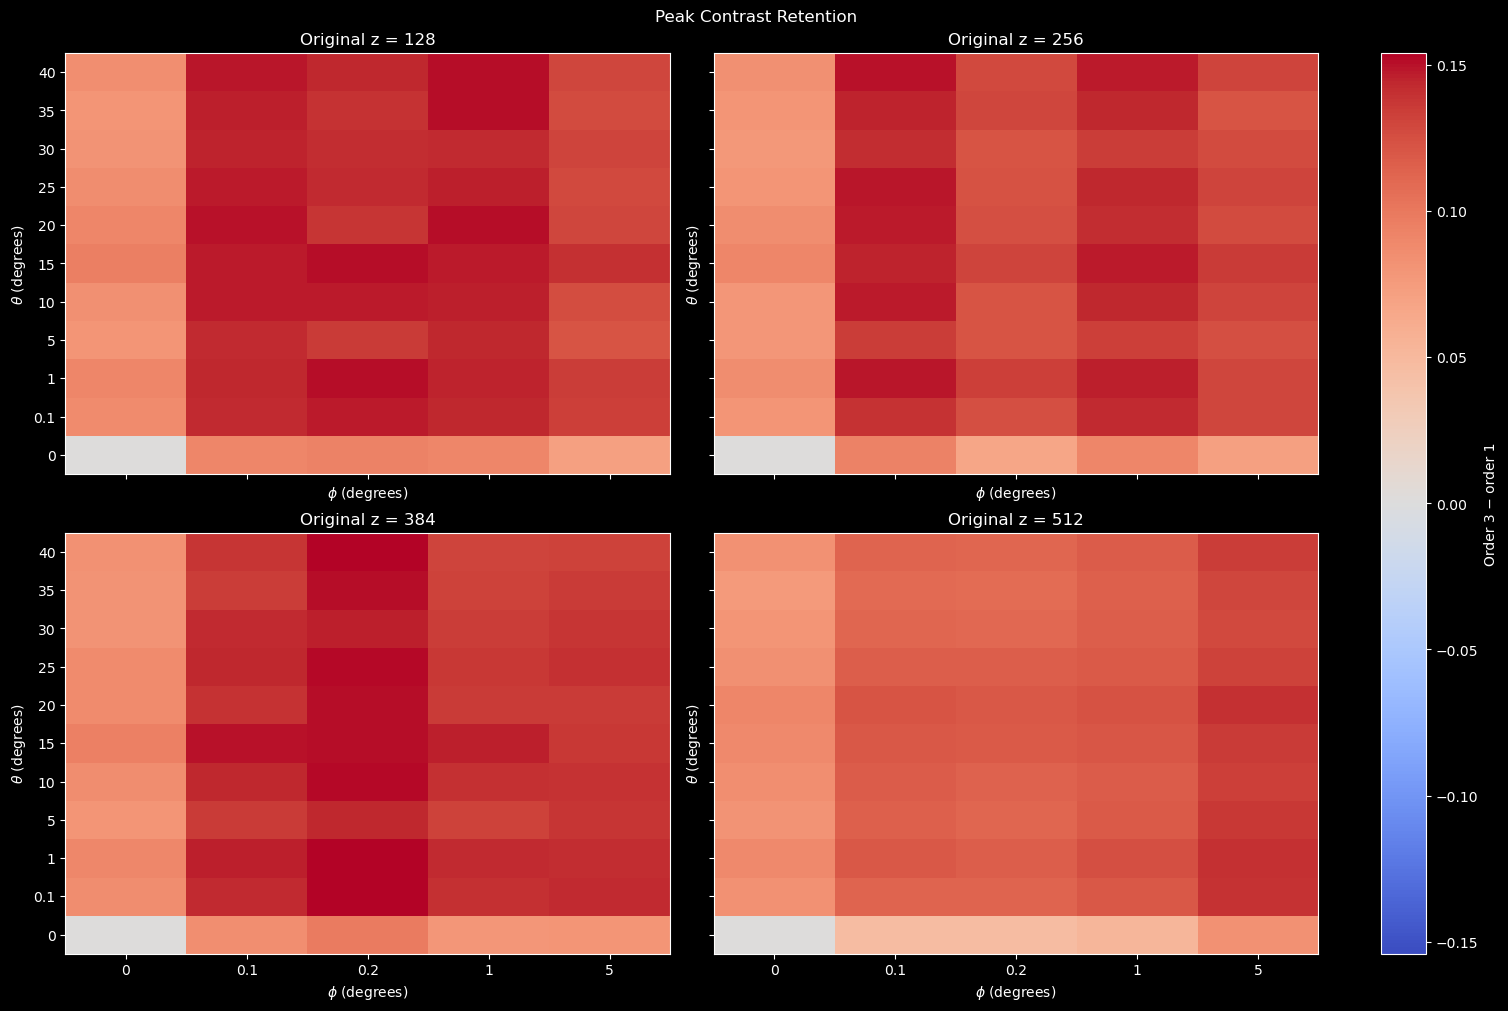

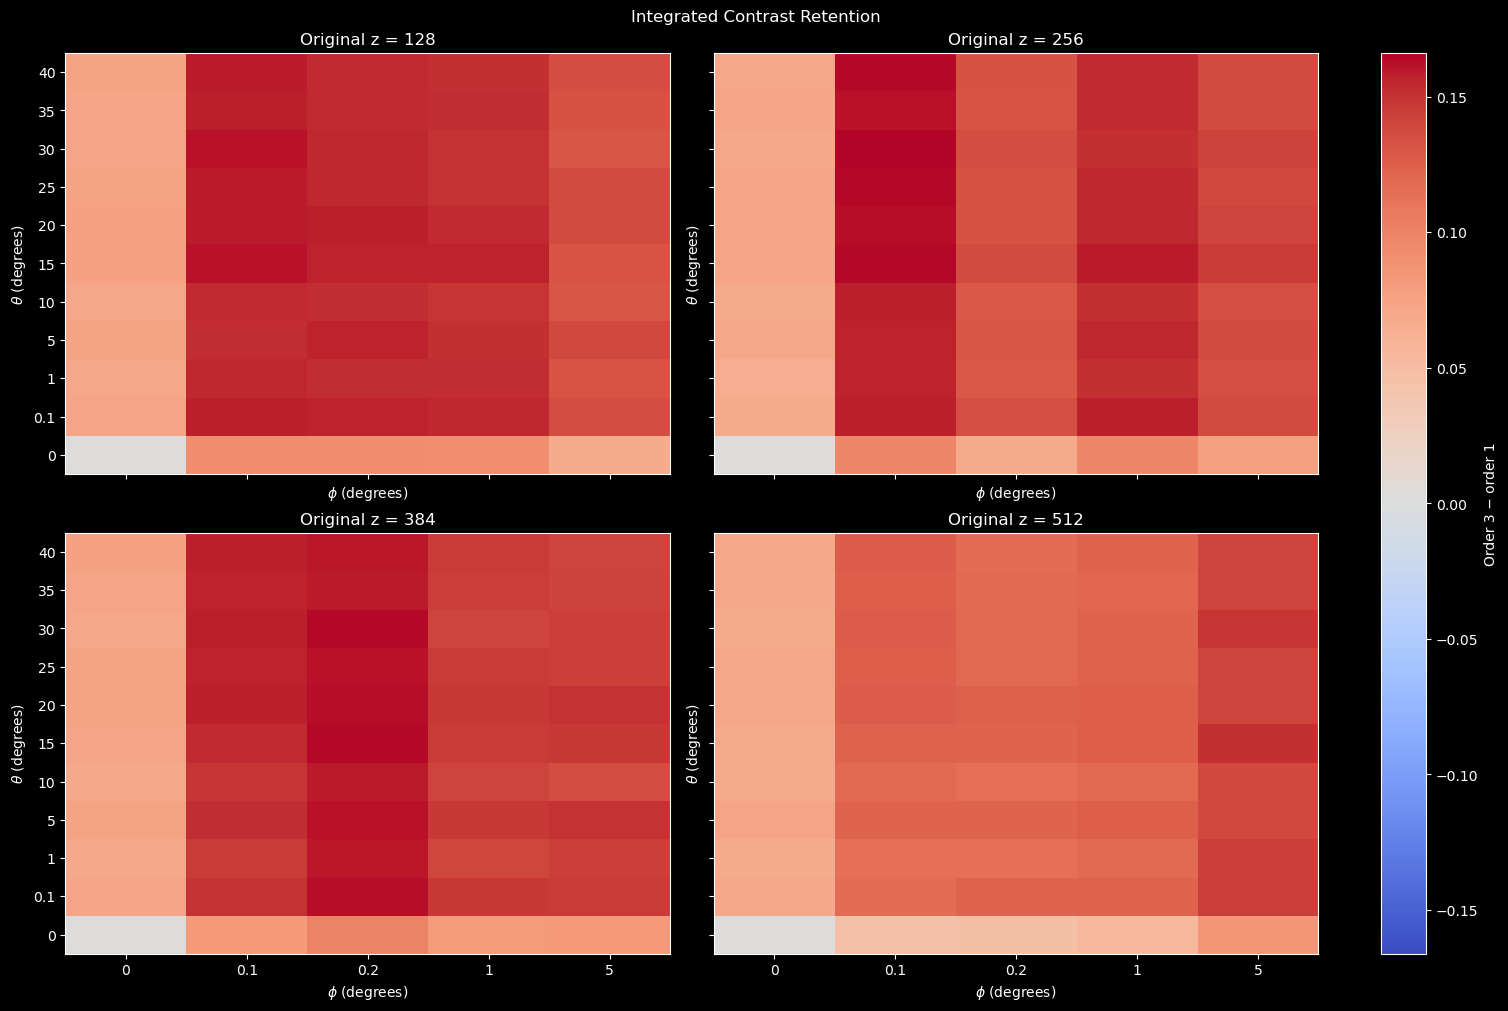

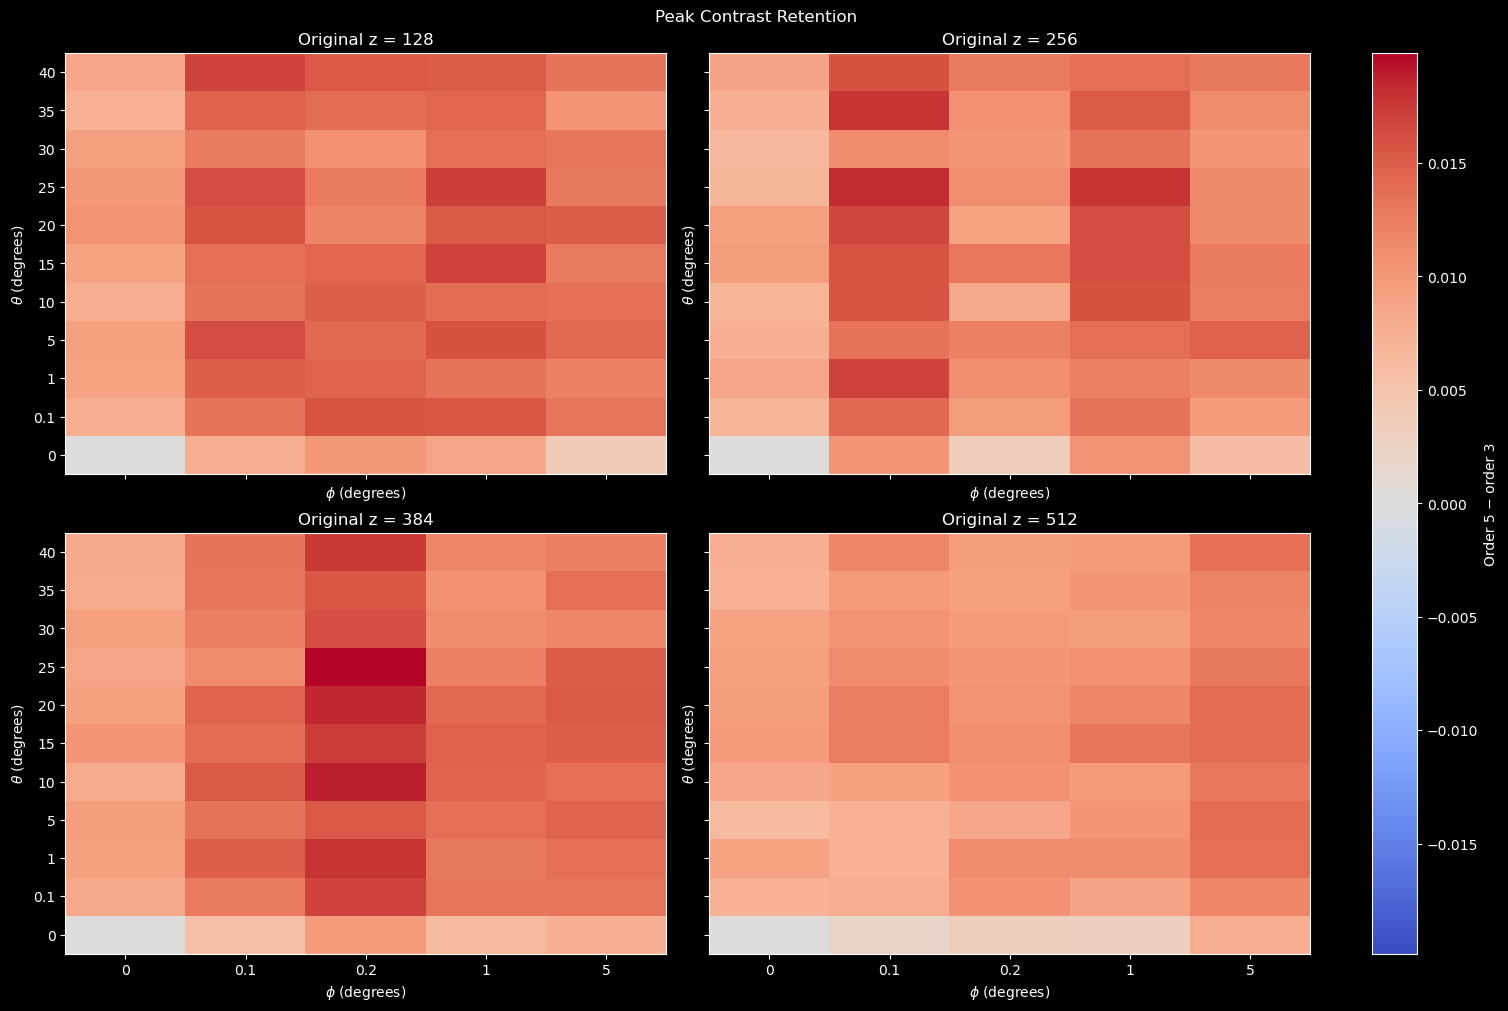

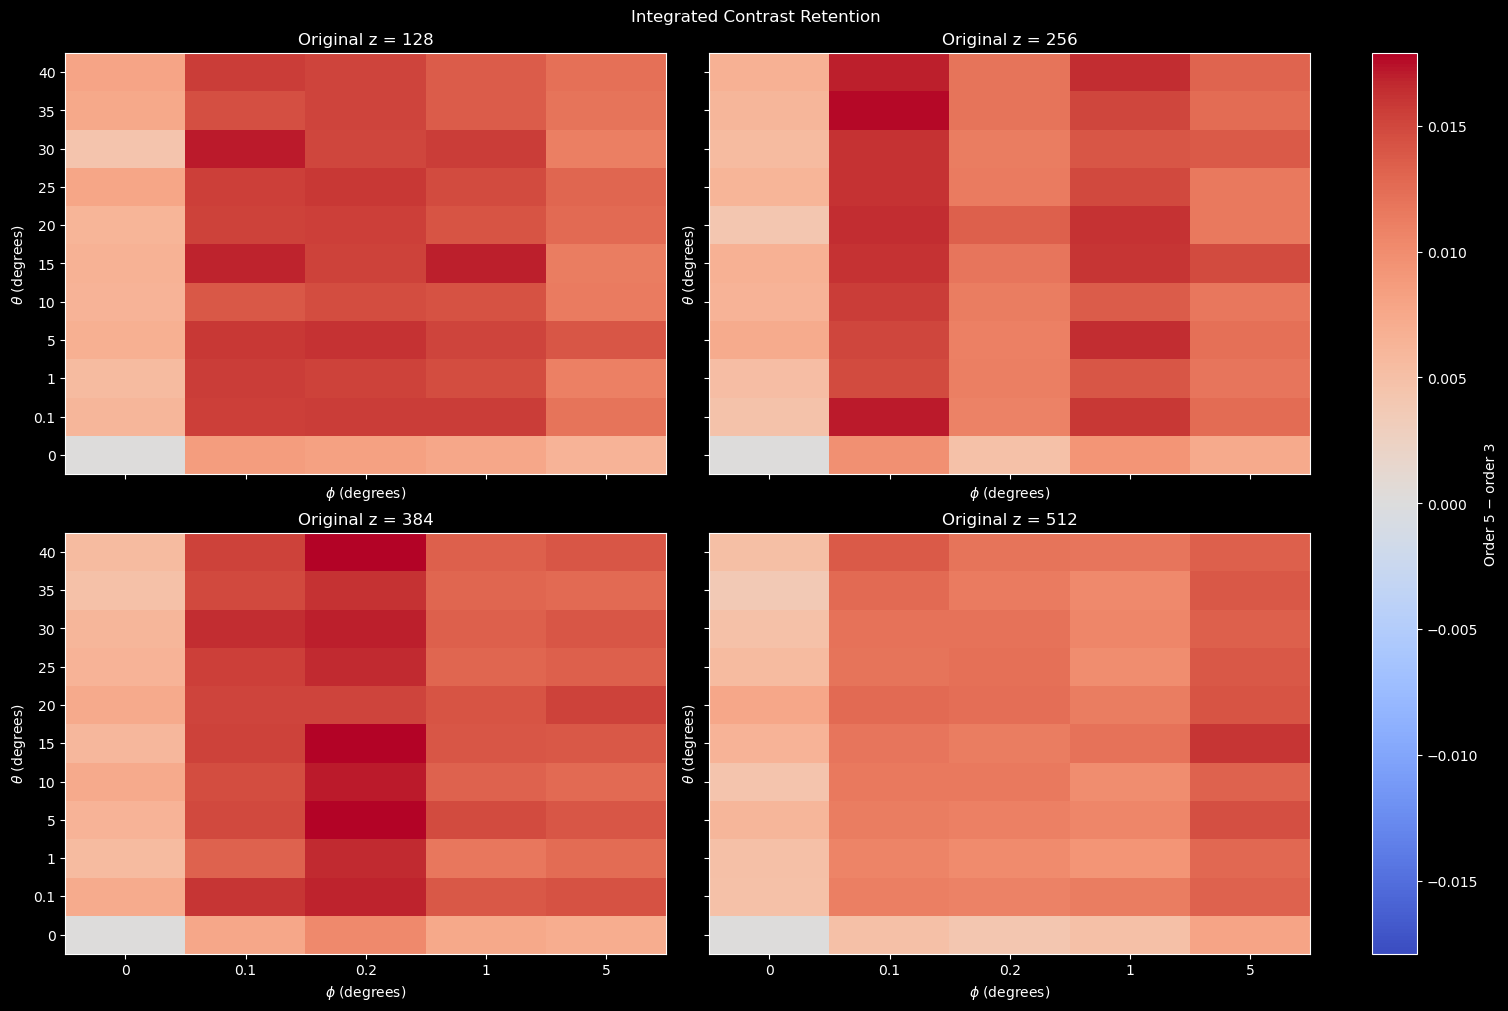

In [34]:
# Paired order comparisons retain the same bit depth, sigma, theta, phi, and
# particle ID. The heatmaps average those matched differences only afterward.
ORDER_COMPARISONS = ((1, 3), (3, 5))
ORDER_METRICS = ("peak_contrast_retention", "integrated_contrast_retention")
order_match_keys = [
    "bit_depth", "particle_sigma", "amplitude_snr", "theta_deg", "phi_deg",
    "particle_id", "top_k", *particle_position_columns,
]
for before_order, after_order in ORDER_COMPARISONS:
    before = df_particle_realized_by_particle.query(
        "interpolation_order == @before_order"
    )
    after = df_particle_realized_by_particle.query(
        "interpolation_order == @after_order"
    )
    paired_orders = before.merge(
        after,
        on=order_match_keys,
        suffixes=("_before", "_after"),
        validate="one_to_one",
    )
    for metric in ORDER_METRICS:
        delta_column = f"{metric}_delta"
        paired_orders[delta_column] = (
            paired_orders[f"{metric}_after"]
            - paired_orders[f"{metric}_before"]
        )
        heatmap_data = (
            paired_orders
            .groupby(["z", "theta_deg", "phi_deg"], as_index=False)[delta_column]
            .mean()
        )
        vmax = heatmap_data[delta_column].abs().max()
        fig, axes = plt.subplots(
            2, 2, figsize=(15, 10), sharex=True, sharey=True,
            layout="constrained",
        )
        image = None
        for axis, z_value in zip(
            axes.flat, sorted(heatmap_data.z.unique()), strict=True
        ):
            grid = (
                heatmap_data.query("z == @z_value")
                .pivot(index="theta_deg", columns="phi_deg", values=delta_column)
            )
            image = axis.imshow(
                grid.to_numpy(),
                origin="lower",
                aspect="auto",
                cmap="coolwarm",
                vmin=-vmax,
                vmax=vmax,
            )
            axis.set_title(f"Original z = {z_value:g}")
            axis.set_xticks(
                range(len(grid.columns)),
                labels=[f"{value:g}" for value in grid.columns],
            )
            axis.set_yticks(
                range(len(grid.index)),
                labels=[f"{value:g}" for value in grid.index],
            )
            axis.set_xlabel(r"$\phi$ (degrees)")
            axis.set_ylabel(r"$\theta$ (degrees)")
        fig.colorbar(
            image,
            ax=axes,
            label=f"Order {after_order} − order {before_order}",
        )
        fig.suptitle(metric.replace("_", " ").title())
        plt.show()


The following cells preserve matched particle IDs, average only across realized noise seeds, and analyze original z position, transformed z displacement, and interpolation-order effects.

### Phi-separated z diagnostic

These plots separate particle contrast retention from the noise factor used by CNR. Each interpolation order gets its own row, and each phi value is shown independently so z-profile structure is not hidden by pooling angles.

peak_contrast_retention  peak_noise_factor  \
phi_deg z                                                   
0.0     128.0                 0.904251           1.182477   
        256.0                 0.907964           1.182106   
        384.0                 0.904287           1.181959   
        512.0                 0.900538           1.182226   
0.1     128.0                 0.777191           1.426935   
        256.0                 0.769822           1.443564   
        384.0                 0.786481           1.396200   
        512.0                 0.818024           1.302536   
0.2     128.0                 0.778217           1.421154   
        256.0                 0.817354           1.347138   
        384.0                 0.769458           1.435846   
        512.0                 0.826118           1.297209   
1.0     128.0                 0.785863           1.420489   
        256.0                 0.777929           1.424638   
        384.0                 0.800223           1.361536   
        512.0                 0.824427           1.324443   
5.0     128.0                 0.811572           1.379297   
        256.0                 0.808360           1.379864   
        384.0                 0.797099           1.380308   
        512.0                 0.788127           1.381206   

               integrated_contrast_retention  integrated_noise_factor  
phi_deg z                                                              
0.0     128.0                       0.930445                 1.182447  
        256.0                       0.933508                 1.182106  
        384.0                       0.931832                 1.181966  
        512.0                       0.932594                 1.182191  
0.1     128.0                       0.855268                 1.426947  
        256.0                       0.853336                 1.443481  
        384.0                       0.863088                 1.396219  
        512.0                       0.895212                 1.302653  
0.2     128.0                       0.856578                 1.421034  
        256.0                       0.882155                 1.347219  
        384.0                       0.852150                 1.435979  
        512.0                       0.896048                 1.297480  
1.0     128.0                       0.857529                 1.420597  
        256.0                       0.857267                 1.424510  
        384.0                       0.871089                 1.361277  
        512.0                       0.892482                 1.325024  
5.0     128.0                       0.877385                 1.379409  
        256.0                       0.875916                 1.379855  
        384.0                       0.868527                 1.380354  
        512.0                       0.866474                 1.381258

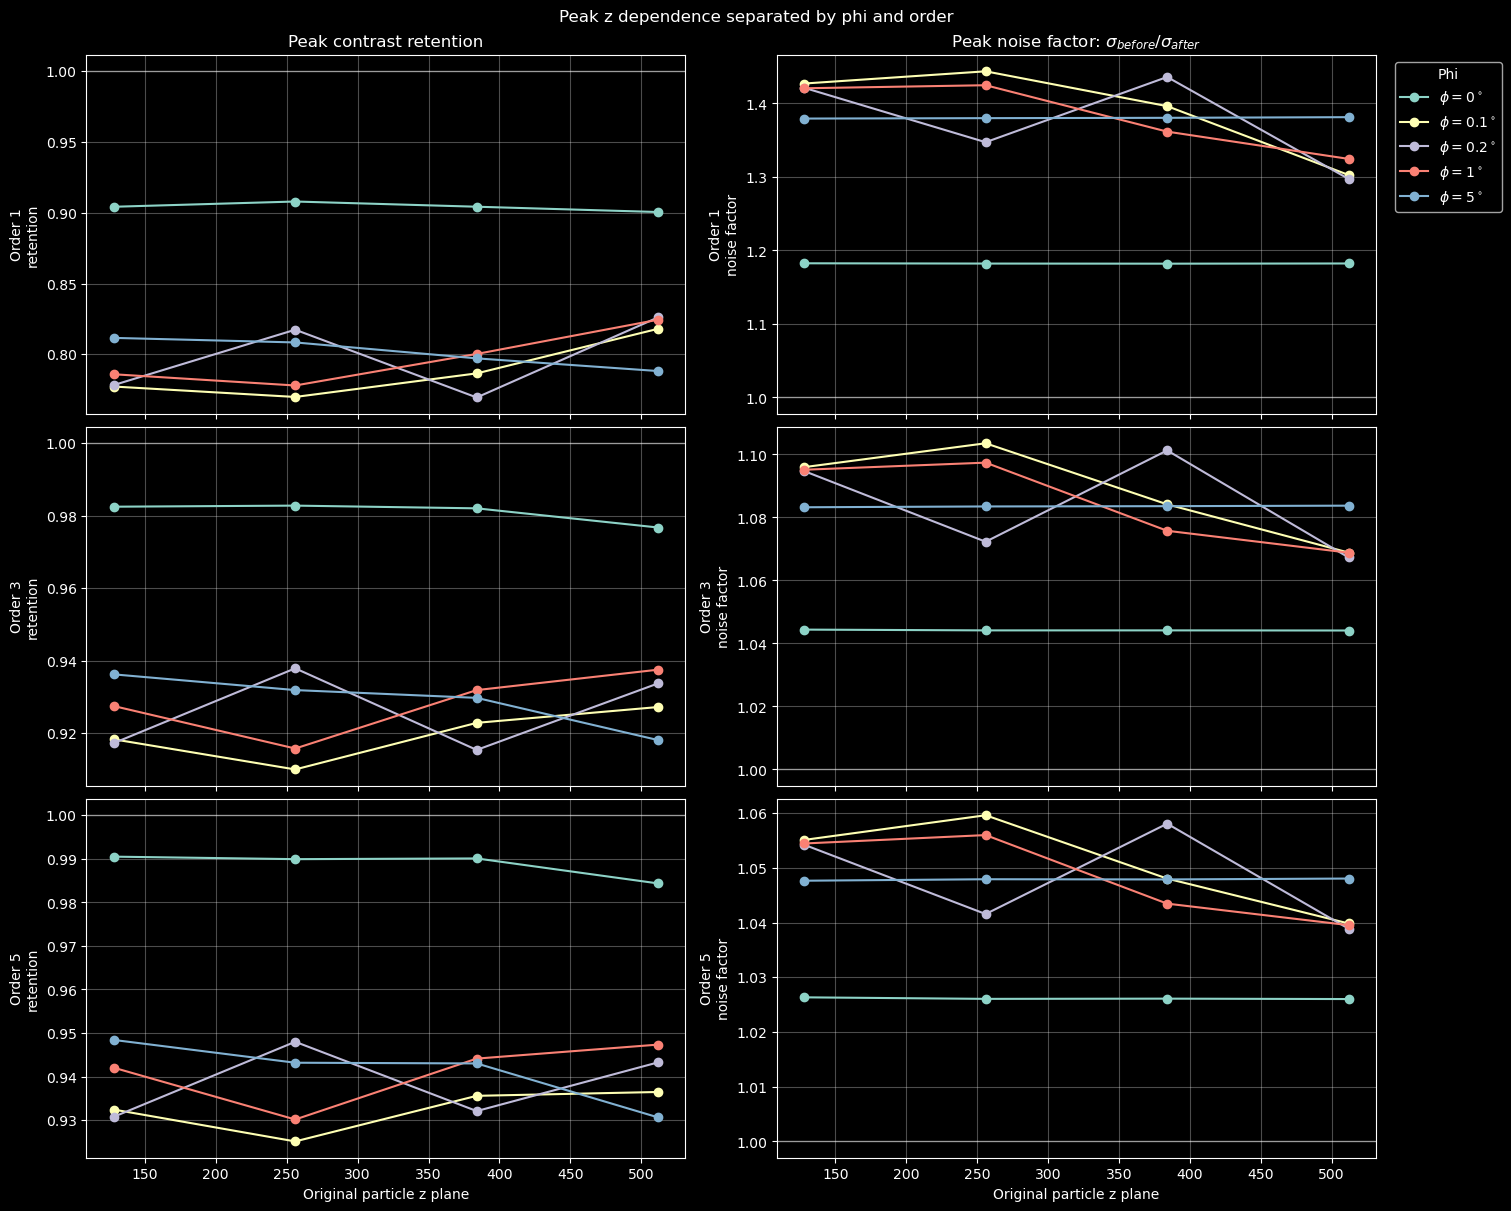

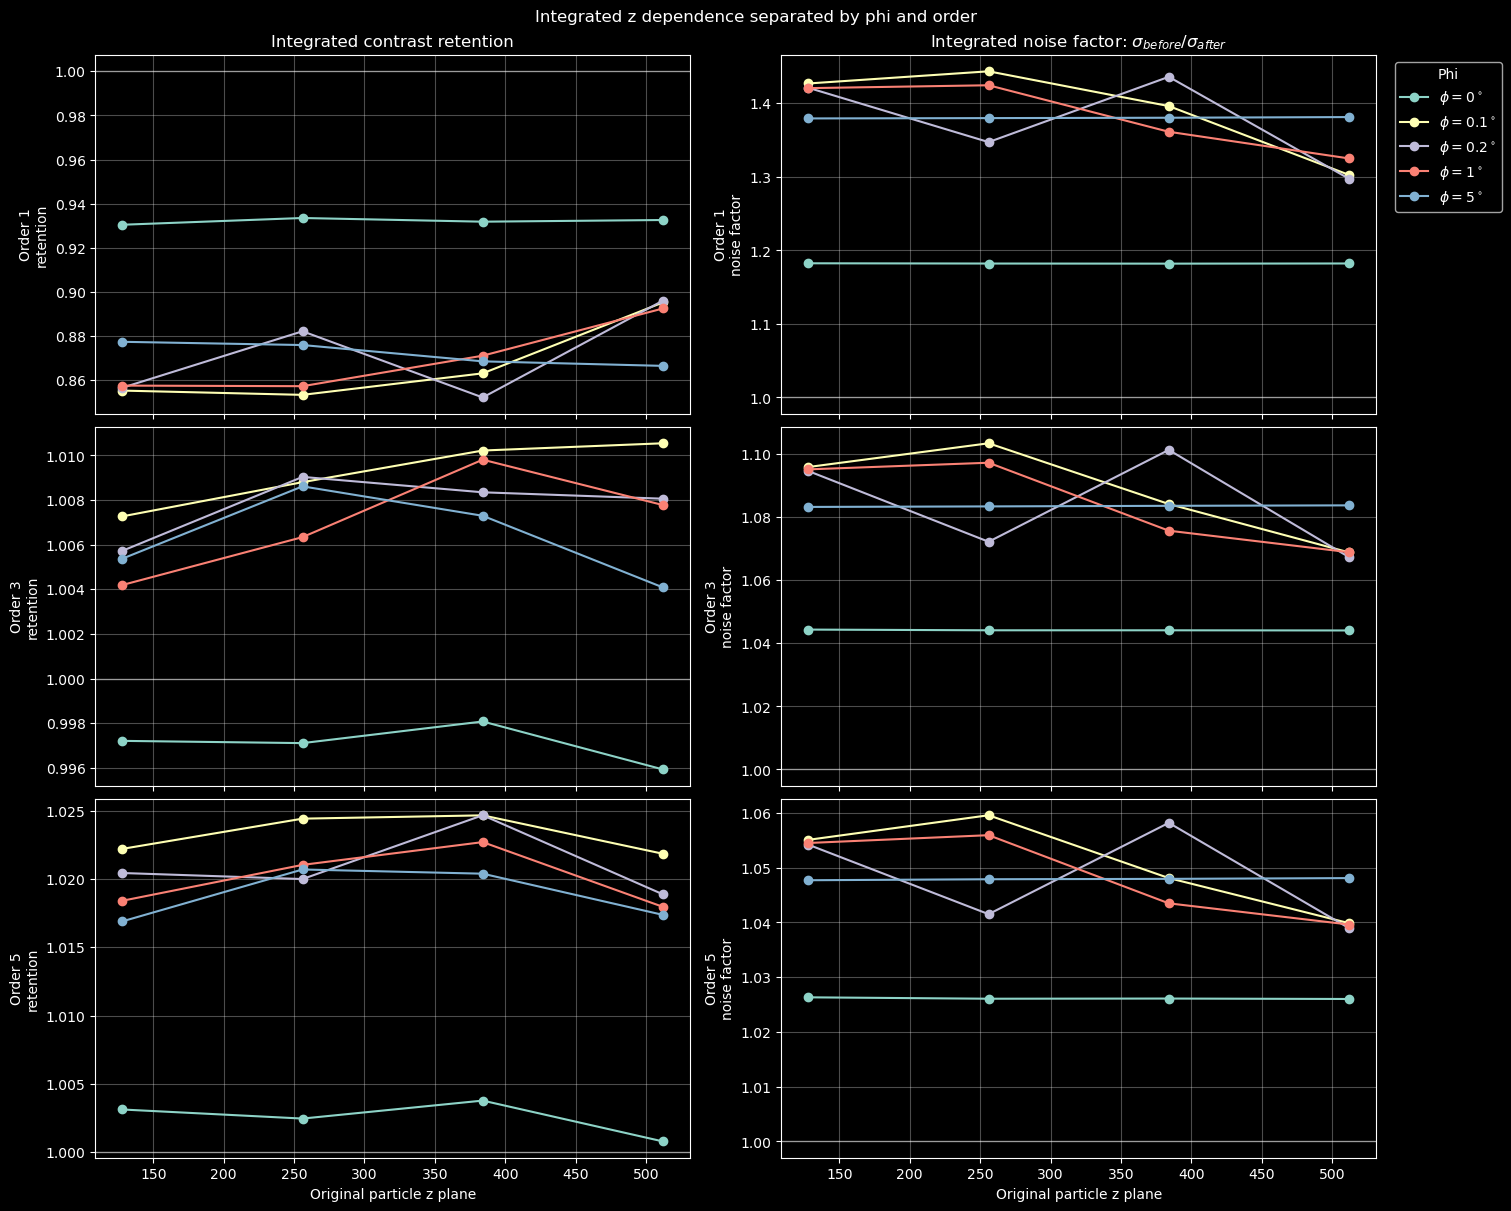

In [35]:
# Decompose CNR retention into particle-contrast retention and the corresponding
# noise factor: CNR retention = contrast retention × (noise_before / noise_after).
phi_z_diagnostic_raw = df_particle_raw.query("noise_seed >= 0").copy()
phi_z_diagnostic_raw["peak_noise_factor"] = (
    phi_z_diagnostic_raw["peak_cnr_retention"]
    / phi_z_diagnostic_raw["peak_contrast_retention"]
)
phi_z_diagnostic_raw["integrated_noise_factor"] = (
    phi_z_diagnostic_raw["integrated_cnr_retention"]
    / phi_z_diagnostic_raw["integrated_contrast_retention"]
)
phi_z_diagnostic_metrics = [
    "peak_contrast_retention",
    "peak_noise_factor",
    "integrated_contrast_retention",
    "integrated_noise_factor",
]
phi_z_diagnostic = (
    phi_z_diagnostic_raw
    .replace([np.inf, -np.inf], np.nan)
    .groupby(["interpolation_order", "phi_deg", "z"], as_index=False)[
        phi_z_diagnostic_metrics
    ]
    .mean()
)

display(
    phi_z_diagnostic.query("interpolation_order == 1")
    .set_index(["phi_deg", "z"])[phi_z_diagnostic_metrics]
)

diagnostic_pairs = [
    ("Peak", "peak_contrast_retention", "peak_noise_factor"),
    ("Integrated", "integrated_contrast_retention", "integrated_noise_factor"),
]
orders = sorted(phi_z_diagnostic.interpolation_order.unique())
for label, contrast_metric, noise_metric in diagnostic_pairs:
    fig, axes = plt.subplots(
        len(orders),
        2,
        figsize=(15, 4 * len(orders)),
        sharex=True,
        layout="constrained",
    )
    for row, order in enumerate(orders):
        order_data = phi_z_diagnostic.query("interpolation_order == @order")
        for phi, group in order_data.groupby("phi_deg"):
            axes[row, 0].plot(
                group["z"],
                group[contrast_metric],
                marker="o",
                label=rf"$\phi={phi:g}^\circ$",
            )
            axes[row, 1].plot(
                group["z"],
                group[noise_metric],
                marker="o",
                label=rf"$\phi={phi:g}^\circ$",
            )
        axes[row, 0].axhline(1.0, color="white", linewidth=1, alpha=0.45)
        axes[row, 1].axhline(1.0, color="white", linewidth=1, alpha=0.45)
        axes[row, 0].set_ylabel(f"Order {order}\nretention")
        axes[row, 1].set_ylabel(f"Order {order}\nnoise factor")
        axes[row, 0].grid(alpha=0.3)
        axes[row, 1].grid(alpha=0.3)
    axes[0, 0].set_title(f"{label} contrast retention")
    axes[0, 1].set_title(
        rf"{label} noise factor: $\sigma_{{before}} / \sigma_{{after}}$"
    )
    axes[-1, 0].set_xlabel("Original particle z plane")
    axes[-1, 1].set_xlabel("Original particle z plane")
    axes[0, 1].legend(title="Phi", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.suptitle(f"{label} z dependence separated by phi and order")
    plt.show()


## Particle size, bit depth, and interpolation order

This view averages the matched particle measurements across realized noise seeds, positions, and rotation angles. It isolates how the original particle size (sigma), storage bit depth, and interpolation order affect retention.

peak_contrast_retention  \
                                                                mean   
particle_sigma bit_depth interpolation_order                           
0.5            uint16    1                                  0.572124   
                         3                                  0.805749   
                         5                                  0.838634   
               uint8     1                                  0.571963   
                         3                                  0.805633   
                         5                                  0.838525   
1.0            uint16    1                                  0.779529   
                         3                                  0.946403   
                         5                                  0.958986   
               uint8     1                                  0.779014   
                         3                                  0.946265   
                         5                                  0.958716   
2.0            uint16    1                                  0.932885   
                         3                                  0.993246   
                         5                                  0.994058   
               uint8     1                                  0.931368   
                         3                                  0.992193   
                         5                                  0.992857   
4.0            uint16    1                                  0.988534   
                         3                                  1.003068   
                         5                                  1.003377   
               uint8     1                                  0.985904   
                         3                                  1.001719   
                         5                                  1.001820   

                                                              \
                                                   std count   
particle_sigma bit_depth interpolation_order                   
0.5            uint16    1                    0.168035  3960   
                         3                    0.175047  3960   
                         5                    0.180536  3960   
               uint8     1                    0.168266  3960   
                         3                    0.175574  3960   
                         5                    0.180900  3960   
1.0            uint16    1                    0.097479  3960   
                         3                    0.085869  3960   
                         5                    0.087720  3960   
               uint8     1                    0.098272  3960   
                         3                    0.086328  3960   
                         5                    0.088358  3960   
2.0            uint16    1                    0.038391  3960   
                         3                    0.033355  3960   
                         5                    0.034343  3960   
               uint8     1                    0.040042  3960   
                         3                    0.034716  3960   
                         5                    0.035377  3960   
4.0            uint16    1                    0.025744  3960   
                         3                    0.025745  3960   
                         5                    0.027947  3960   
               uint8     1                    0.029490  3960   
                         3                    0.028001  3960   
                         5                    0.029471  3960   

                                             integrated_contrast_retention  \
                                                                      mean   
particle_sigma bit_depth interpolation_order                                 
0.5            uint16    1                                        0.763898   
                         3                                 

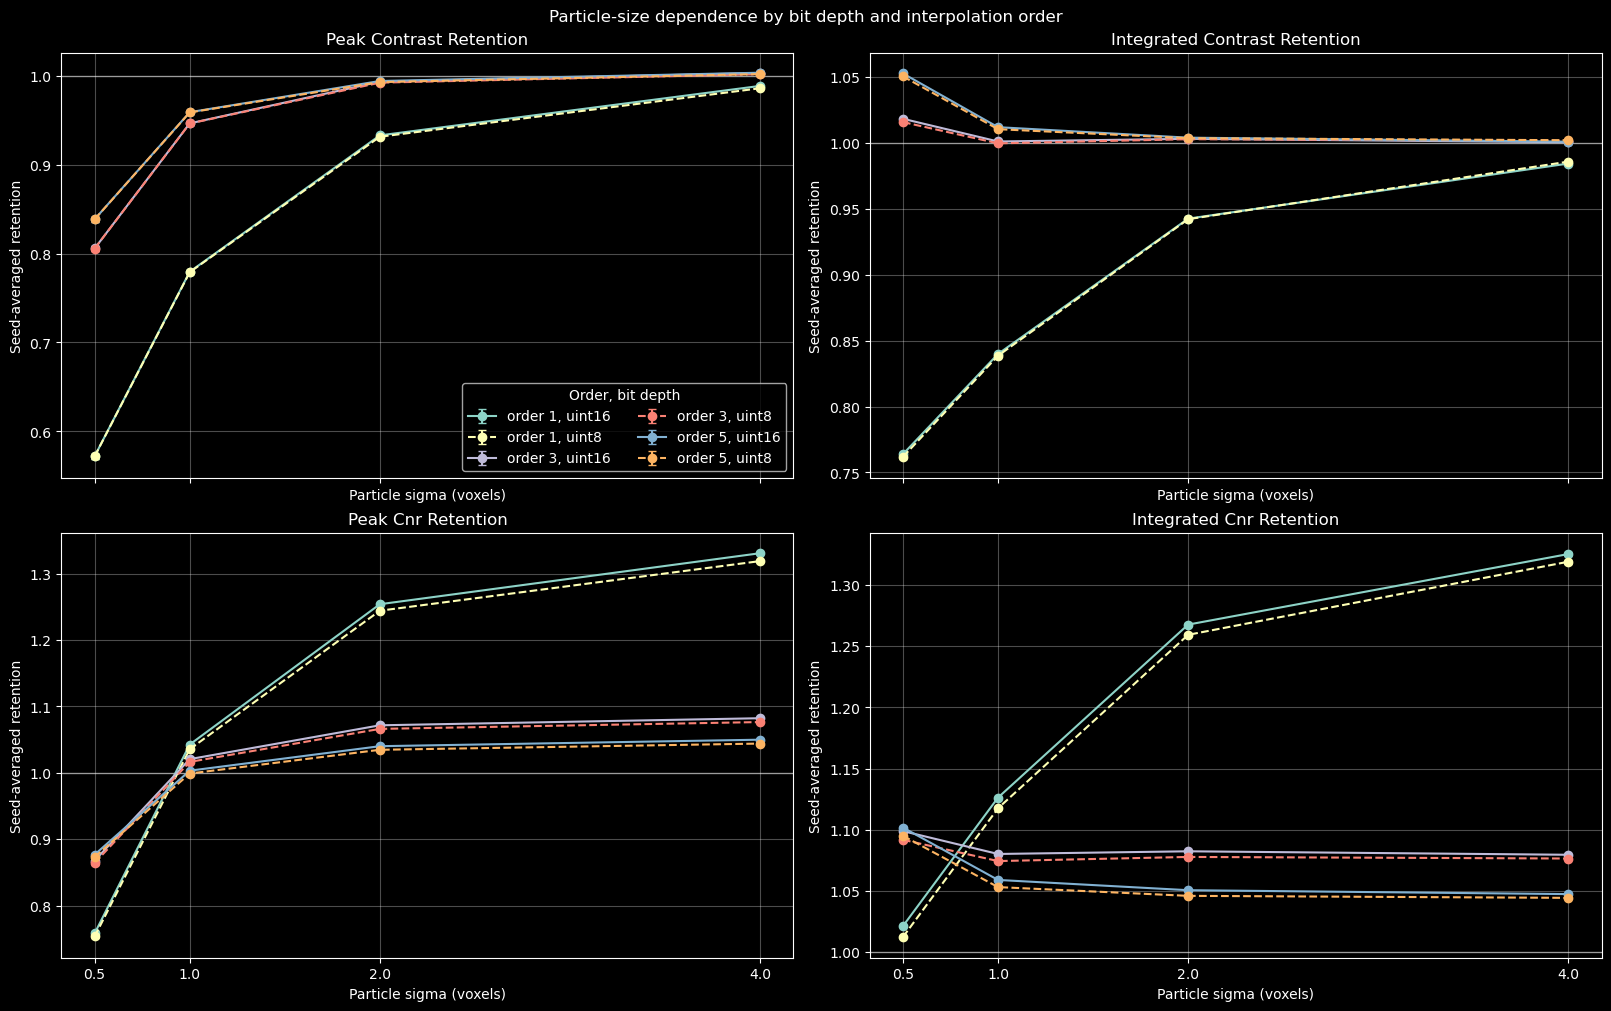

In [36]:
# Compare only the size, bit-depth, and interpolation-order dimensions.
# All plotted values first average the independent realized-noise seeds.
sigma_order_bit_depth = (
    df_particle_realized_by_particle
    .groupby(["particle_sigma", "bit_depth", "interpolation_order"], as_index=False)[
        retention_metrics
    ]
    .agg(["mean", "std", "count"])
)

display(
    sigma_order_bit_depth
    .set_index(["particle_sigma", "bit_depth", "interpolation_order"])
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, layout="constrained")
bit_depth_styles = {"uint8": "--", "uint16": "-"}
for axis, metric in zip(axes.flat, retention_metrics, strict=True):
    metric_summary = (
        df_particle_realized_by_particle
        .groupby(["particle_sigma", "bit_depth", "interpolation_order"])[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    for (order, bit_depth), group in metric_summary.groupby(
        ["interpolation_order", "bit_depth"]
    ):
        sem = group["std"] / np.sqrt(group["count"])
        axis.errorbar(
            group["particle_sigma"],
            group["mean"],
            yerr=sem,
            marker="o",
            linestyle=bit_depth_styles[bit_depth],
            capsize=3,
            label=f"order {order}, {bit_depth}",
        )
    axis.axhline(1.0, color="white", linewidth=1, alpha=0.45)
    axis.set_title(metric.replace("_", " ").title())
    axis.set_xlabel("Particle sigma (voxels)")
    axis.set_ylabel("Seed-averaged retention")
    axis.set_xticks(sorted(metric_summary["particle_sigma"].unique()))
    axis.grid(alpha=0.3)
axes[0, 0].legend(title="Order, bit depth", ncols=2)
fig.suptitle("Particle-size dependence by bit depth and interpolation order")
plt.show()


### Absolute contrast and CNR

Retention alone can conceal the magnitude of the underlying measurements. These plots show the actual pre-rotation and post-rotation contrast and CNR values.

peak_contrast_before  \
particle_sigma bit_depth interpolation_order                         
0.5            uint16    1                            10191.950558   
                         3                            10191.950558   
                         5                            10191.950558   
               uint8     1                               39.647272   
                         3                               39.647272   
                         5                               39.647272   
1.0            uint16    1                            10191.923274   
                         3                            10191.923274   
                         5                            10191.923274   
               uint8     1                               39.647165   
                         3                               39.647165   
                         5                               39.647165   
2.0            uint16    1                            10191.923274   
                         3                            10191.923274   
                         5                            10191.923274   
               uint8     1                               39.647165   
                         3                               39.647165   
                         5                               39.647165   
4.0            uint16    1                            10191.923274   
                         3                            10191.923274   
                         5                            10191.923274   
               uint8     1                               39.647165   
                         3                               39.647165   
                         5                               39.647165   

                                              peak_contrast_after  \
particle_sigma bit_depth interpolation_order                        
0.5            uint16    1                            5844.161430   
                         3                            8216.012118   
                         5                            8549.344615   
               uint8     1                              22.725493   
                         3                              31.953228   
                         5                              33.250014   
1.0            uint16    1                            7933.285029   
                         3                            9630.541850   
                         5                            9759.095736   
               uint8     1                              30.838266   
                         3                              37.454888   
                         5                              37.950661   
2.0            uint16    1                            9477.601291   
                         3                           10100.925234   
                         5                           10110.730029   
               uint8     1                              36.807761   
                         3                              39.251504   
                         5                              39.283995   
4.0            uint16    1                           10037.965786   
                         3                           10199.356598   
                         5                           10202.120281   
               uint8     1                              38.932003   
                         3                              39.620393   
                         5                              39.622177   

                                              integrated_contrast_before  \
particle_sigma bit_depth interpolation_order                               
0.5            uint16    1                                  29341.240014   
                         3                                  29341.240014   
                         5                                  29341.240014   
               uint8     1                        

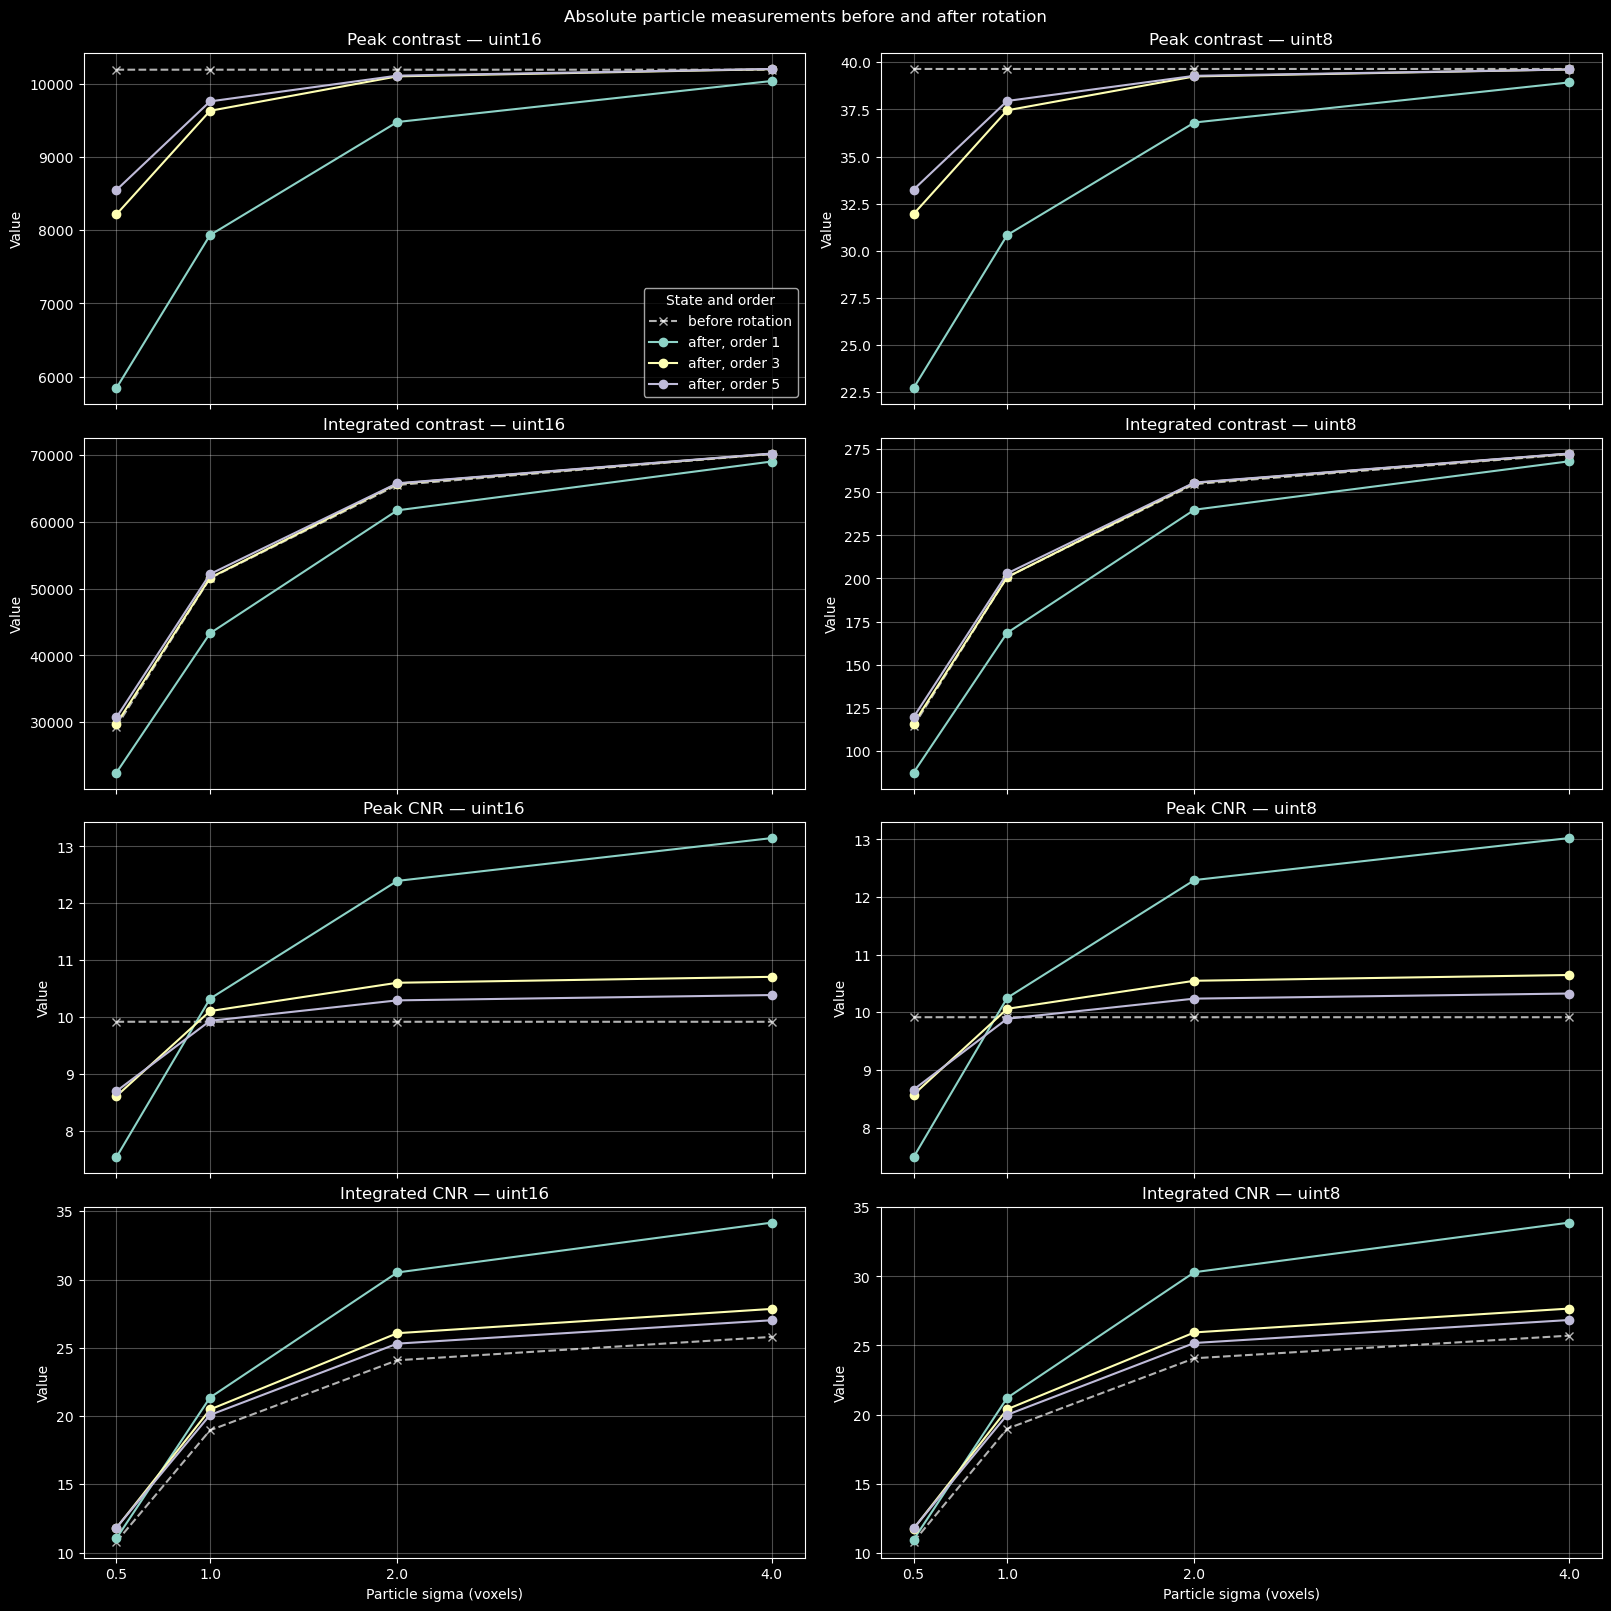

In [37]:
absolute_metrics = [
    ("peak_contrast", "Peak contrast"),
    ("integrated_contrast", "Integrated contrast"),
    ("peak_cnr", "Peak CNR"),
    ("integrated_cnr", "Integrated CNR"),
]
absolute_value_columns = [
    f"{metric}_{state}" for metric, _ in absolute_metrics
    for state in ("before", "after")
]

# Average independent noise realizations first, then summarize the remaining
# particle positions and rotation conditions by size, bit depth, and order.
absolute_by_particle = (
    df_particle_raw.query("noise_seed >= 0")
    .groupby(seed_average_keys, as_index=False)[absolute_value_columns]
    .mean()
)
absolute_summary = (
    absolute_by_particle
    .groupby(["particle_sigma", "bit_depth", "interpolation_order"], as_index=False)[
        absolute_value_columns
    ]
    .mean()
)

display(
    absolute_summary
    .set_index(["particle_sigma", "bit_depth", "interpolation_order"])
)

bit_depths = sorted(absolute_summary["bit_depth"].unique())
fig, axes = plt.subplots(
    len(absolute_metrics), len(bit_depths), figsize=(16, 16),
    sharex="col", layout="constrained",
)
for column, bit_depth in enumerate(bit_depths):
    bit_depth_data = absolute_summary.query("bit_depth == @bit_depth")
    for row, (metric, label) in enumerate(absolute_metrics):
        axis = axes[row, column]
        # Pre-rotation values are not order-dependent; show one baseline.
        before = (
            bit_depth_data
            .groupby("particle_sigma", as_index=False)[f"{metric}_before"]
            .mean()
        )
        axis.plot(
            before["particle_sigma"], before[f"{metric}_before"],
            color="white", linestyle="--", marker="x", alpha=0.7,
            label="before rotation",
        )
        for order, group in bit_depth_data.groupby("interpolation_order"):
            axis.plot(
                group["particle_sigma"], group[f"{metric}_after"],
                marker="o", label=f"after, order {order}",
            )
        axis.set_title(f"{label} — {bit_depth}")
        axis.set_ylabel("Value")
        axis.set_xticks(sorted(bit_depth_data["particle_sigma"].unique()))
        axis.grid(alpha=0.3)
        if row == 0 and column == 0:
            axis.legend(title="State and order")
for axis in axes[-1]:
    axis.set_xlabel("Particle sigma (voxels)")
fig.suptitle("Absolute particle measurements before and after rotation")
plt.show()


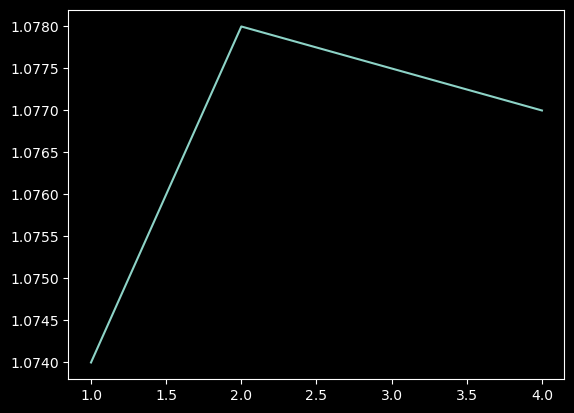

In [38]:
#plt.plot([1,2,4],[1.118,1.259,1.319])
plt.plot([1,2,4],[1.074,1.078,1.077])